In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
!pip install -q kaggle

In [7]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [8]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2) (1).zip


In [9]:
import zipfile
import os

with zipfile.ZipFile("archive (2).zip", "r") as zip_ref:
    zip_ref.extractall("house_price_data")

print(os.listdir("house_price_data"))

['house_prices.csv']


In [10]:
import pandas as pd

df = pd.read_csv("house_price_data/house_prices.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData info:")
df.info()

Shape: (187531, 21)

Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']

First 5 rows:


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  obj

In [11]:
missing = df.isna().sum().sort_values(ascending=False)

missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percent.round(2)
})

display(missing_table)

,Missing Values,Missing %
Plot Area,187531,100.00
Dimensions,187531,100.00
Society,109678,58.49
Super Area,107685,57.42
Car Parking,103357,55.11
overlooking,81436,43.43
Carpet Area,80673,43.02
facing,70233,37.45
Ownership,65517,34.94
Balcony,48935,26.09


In [12]:
import re

df_clean = df.copy()

def parse_price(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower().replace(",", "")

    # Call for Price
    if "call" in value:
        return np.nan

    # Crore
    if "cr" in value:
        number = re.findall(r"[\d.]+", value)
        if number:
            return float(number[0]) * 10_000_000

    # Lakh
    if "lac" in value or "lakh" in value:
        number = re.findall(r"[\d.]+", value)
        if number:
            return float(number[0]) * 100_000

    # Normal numeric value
    number = re.findall(r"[\d.]+", value)
    if number:
        return float(number[0])

    return np.nan


df_clean["price_clean"] = df_clean["Amount(in rupees)"].apply(parse_price)

print(df_clean[["Amount(in rupees)", "price_clean"]].head(10))
print("\nMissing target values:", df_clean["price_clean"].isna().sum())

  Amount(in rupees)  price_clean
0           42 Lac     4200000.0
1           98 Lac     9800000.0
2          1.40 Cr    14000000.0
3           25 Lac     2500000.0
4          1.60 Cr    16000000.0
5           45 Lac     4500000.0
6         16.5 Lac     1650000.0
7           60 Lac     6000000.0
8           60 Lac     6000000.0
9          1.60 Cr    16000000.0

Missing target values: 9684


In [13]:
def parse_area(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # استخراج الرقم
    numbers = re.findall(r"[\d.]+", value)

    if not numbers:
        return np.nan

    # لو فيه مدى مثل 1000 - 1200 ناخد المتوسط
    nums = [float(x) for x in numbers]
    number = sum(nums) / len(nums)

    # تحويل square meter إلى square feet
    if "sqm" in value or "sq m" in value or "square meter" in value:
        return number * 10.7639

    # لو بالفعل sqft
    return number


df_clean["carpet_area_sqft"] = df_clean["Carpet Area"].apply(parse_area)

print(df_clean[["Carpet Area", "carpet_area_sqft"]].head(15))

print("\nMissing Carpet Area:",
      df_clean["carpet_area_sqft"].isna().sum())

   Carpet Area  carpet_area_sqft
0     500 sqft             500.0
1     473 sqft             473.0
2     779 sqft             779.0
3     530 sqft             530.0
4     635 sqft             635.0
5          NaN               NaN
6     550 sqft             550.0
7          NaN               NaN
8          NaN               NaN
9     900 sqft             900.0
10    950 sqft             950.0
11         NaN               NaN
12         NaN               NaN
13   1820 sqft            1820.0
14         NaN               NaN

Missing Carpet Area: 80673


In [14]:
def extract_number(value):
    if pd.isna(value):
        return np.nan

    numbers = re.findall(r"[\d.]+", str(value))

    if numbers:
        return float(numbers[0])

    return np.nan


# Bathroom
df_clean["bathroom"] = df_clean["Bathroom"].apply(extract_number)

# Balcony
df_clean["balcony"] = df_clean["Balcony"].apply(extract_number)

# Car Parking
df_clean["car_parking"] = df_clean["Car Parking"].apply(extract_number)


print(df_clean[[
    "Bathroom",
    "bathroom",
    "Balcony",
    "balcony",
    "Car Parking",
    "car_parking"
]].head(15))

   Bathroom  bathroom Balcony  balcony Car Parking  car_parking
0         1       1.0       2      2.0         NaN          NaN
1         2       2.0     NaN      NaN      1 Open          1.0
2         2       2.0     NaN      NaN   1 Covered          1.0
3         1       1.0       1      1.0         NaN          NaN
4         2       2.0     NaN      NaN   1 Covered          1.0
5         1       1.0       1      1.0         NaN          NaN
6         1       1.0     NaN      NaN         NaN          NaN
7         1       1.0     NaN      NaN         NaN          NaN
8         1       1.0     NaN      NaN         NaN          NaN
9         3       3.0       1      1.0   1 Covered          1.0
10        2       2.0     NaN      NaN      1 Open          1.0
11        2       2.0     NaN      NaN         NaN          NaN
12        2       2.0     NaN      NaN         NaN          NaN
13        4       4.0       1      1.0   2 Covered          2.0
14        1       1.0     NaN      NaN  

In [15]:
def parse_floor(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Ground floor
    if "ground" in value:
        return 0.0

    # Basement
    if "basement" in value:
        return -1.0

    # Extract first number
    numbers = re.findall(r"\d+", value)

    if numbers:
        return float(numbers[0])

    return np.nan


df_clean["floor_num"] = df_clean["Floor"].apply(parse_floor)

print(df_clean[["Floor", "floor_num"]].head(20))

print("\nMissing Floor:",
      df_clean["floor_num"].isna().sum())

              Floor  floor_num
0      10 out of 11       10.0
1       3 out of 22        3.0
2      10 out of 29       10.0
3        1 out of 3        1.0
4      20 out of 42       20.0
5        2 out of 7        2.0
6        4 out of 5        4.0
7   Ground out of 7        0.0
8   Ground out of 2        0.0
9       3 out of 27        3.0
10      6 out of 20        6.0
11     16 out of 24       16.0
12      8 out of 20        8.0
13     18 out of 27       18.0
14       2 out of 3        2.0
15     10 out of 16       10.0
16       5 out of 7        5.0
17       4 out of 5        4.0
18     20 out of 28       20.0
19       3 out of 3        3.0

Missing Floor: 7077


In [16]:
# الأعمدة النصية اللي هنستخدمها
categorical_cols = [
    "location",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

# تنظيف النصوص
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# أكثر 50 Location انتشارًا
top_locations = df_clean["location"].value_counts().head(50).index

# تجميع باقي المناطق تحت other
df_clean["location_grouped"] = df_clean["location"].where(
    df_clean["location"].isin(top_locations),
    "other"
)

print("Number of locations before grouping:",
      df_clean["location"].nunique())

print("Number of locations after grouping:",
      df_clean["location_grouped"].nunique())

print("\nTop locations:")
print(df_clean["location_grouped"].value_counts().head(10))

Number of locations before grouping: 81
Number of locations after grouping: 51

Top locations:
location_grouped
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
hyderabad        12300
chennai          10500
jaipur            8490
greater-noida     4710
faridabad         3840
Name: count, dtype: Int64


In [17]:
# حذف الأعمدة غير المفيدة
columns_to_drop = [
    "Index",
    "Title",
    "Description",
    "Price (in rupees)",
    "Plot Area",
    "Dimensions",
    "Society",
    "Super Area",
    "overlooking",
    "Status",
    "Carpet Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "location"
]

df_model = df_clean.drop(columns=columns_to_drop)

# حذف الصفوف التي لا تحتوي على Target
df_model = df_model.dropna(subset=["price_clean"])

print("Shape:", df_model.shape)

print("\nColumns:")
print(df_model.columns.tolist())

print("\nMissing values:")
print(df_model.isna().sum())

Shape: (177847, 12)

Columns:
['Amount(in rupees)', 'Transaction', 'Furnishing', 'facing', 'Ownership', 'price_clean', 'carpet_area_sqft', 'bathroom', 'balcony', 'car_parking', 'floor_num', 'location_grouped']

Missing values:
Amount(in rupees)        0
Transaction             67
Furnishing            2067
facing               65736
Ownership            61925
price_clean              0
carpet_area_sqft     76325
bathroom               760
balcony              47159
car_parking          95912
floor_num             6949
location_grouped         0
dtype: int64


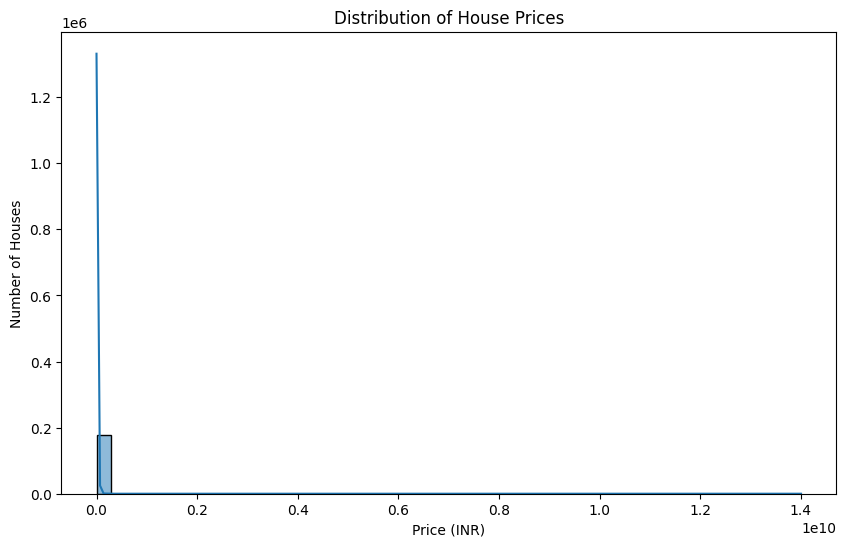

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_model["price_clean"],
    bins=50,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Houses")
plt.show()

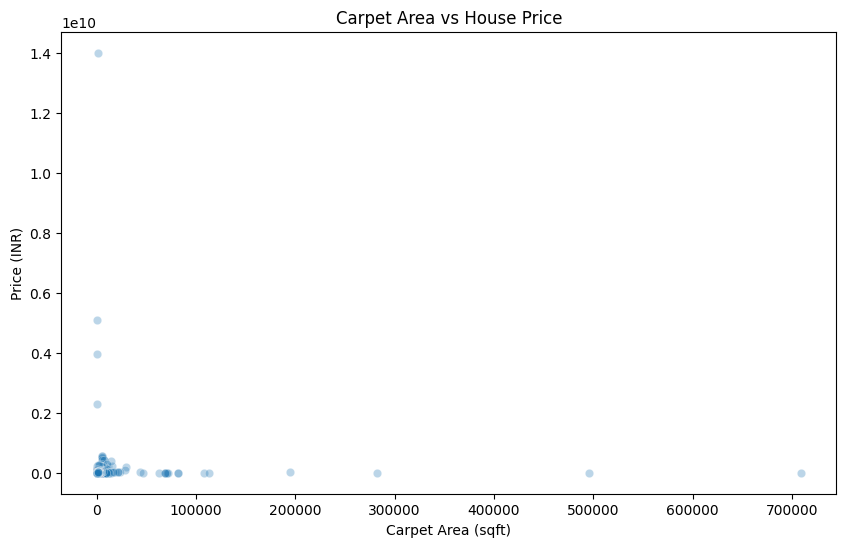

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_model,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.3
)

plt.title("Carpet Area vs House Price")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR)")
plt.show()

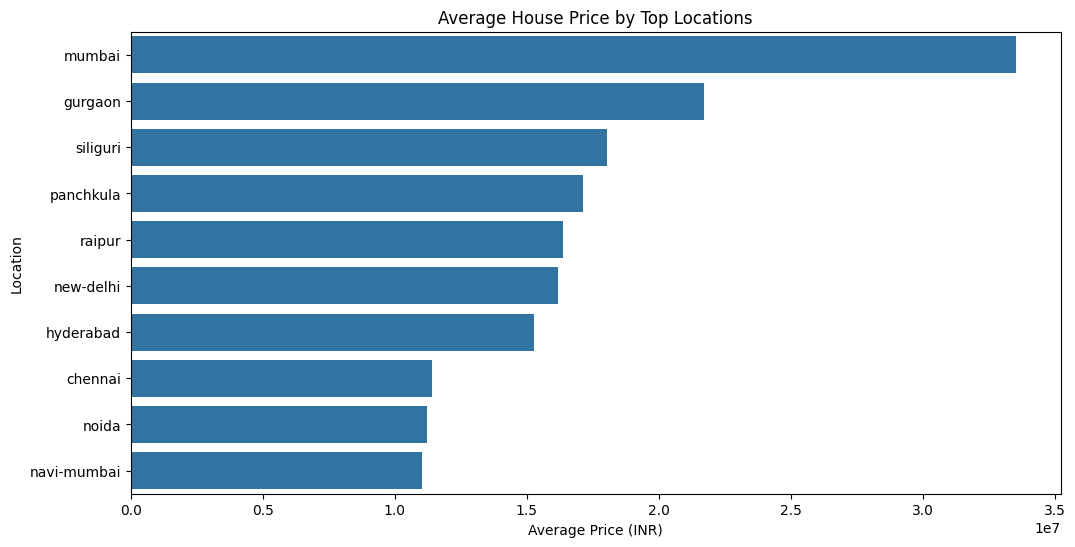

In [20]:
top_10_locations = (
    df_model.groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_locations.values,
    y=top_10_locations.index
)

plt.title("Average House Price by Top Locations")
plt.xlabel("Average Price (INR)")
plt.ylabel("Location")
plt.show()

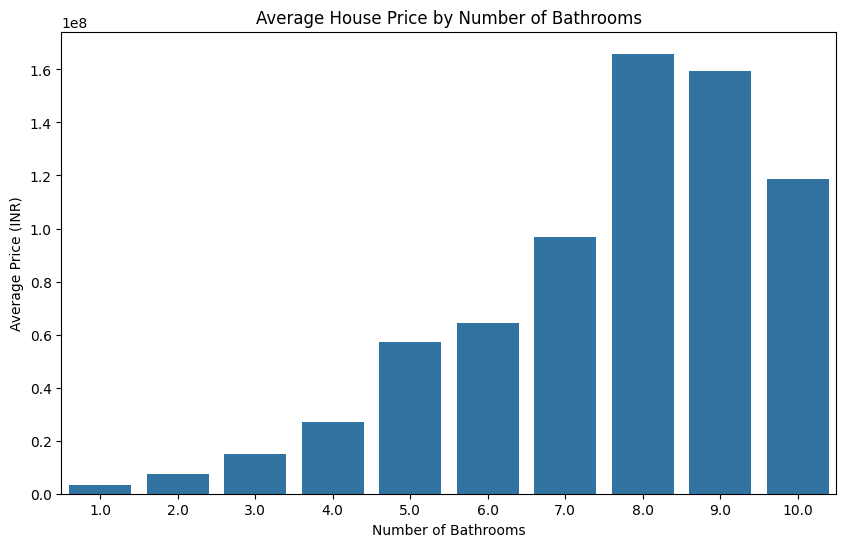

In [21]:
bathroom_price = (
    df_model.groupby("bathroom")["price_clean"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=bathroom_price,
    x="bathroom",
    y="price_clean"
)

plt.title("Average House Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Price (INR)")
plt.show()

In [22]:
# Calculate price per square foot
df_model["price_per_sqft"] = (
    df_model["price_clean"] / df_model["carpet_area_sqft"]
)

# Remove invalid values
df_model = df_model[
    (df_model["carpet_area_sqft"] > 0) &
    (df_model["price_per_sqft"] > 0)
].copy()

# Calculate 1st and 99th percentiles
lower = df_model["price_per_sqft"].quantile(0.01)
upper = df_model["price_per_sqft"].quantile(0.99)

print("1st percentile:", lower)
print("99th percentile:", upper)

# Remove outliers
df_model = df_model[
    (df_model["price_per_sqft"] >= lower) &
    (df_model["price_per_sqft"] <= upper)
].copy()

print("\nShape after removing outliers:", df_model.shape)

1st percentile: 2705.8823529411766
99th percentile: 101503.75939849624

Shape after removing outliers: (99968, 13)


In [23]:
# Target
y = df_model["price_clean"]

# Features
X = df_model.drop(
    columns=[
        "price_clean",
        "price_per_sqft",
        "Amount(in rupees)"
    ]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (99968, 10)
y shape: (99968,)

Features:
['Transaction', 'Furnishing', 'facing', 'Ownership', 'carpet_area_sqft', 'bathroom', 'balcony', 'car_parking', 'floor_num', 'location_grouped']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (79974, 10)
X_test: (19994, 10)
y_train: (79974,)
y_test: (19994,)


In [29]:
# Fix missing categorical values
for col in categorical_features:
    X_train[col] = X_train[col].astype("object").where(X_train[col].notna(), np.nan)
    X_test[col] = X_test[col].astype("object").where(X_test[col].notna(), np.nan)

# Create preprocessor again
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Linear Regression
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [32]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        max_depth=15
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
linear_pred = linear_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)

# Linear Regression metrics
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = mean_squared_error(y_test, linear_pred) ** 0.5
linear_r2 = r2_score(y_test, linear_pred)

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression:")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

print("\nRandom Forest:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Linear Regression:
MAE: 4558858.605524028
RMSE: 7502962.440369338
R²: 0.7204443140003571

Random Forest:
MAE: 1252790.6986787103
RMSE: 4029916.1624542703
R²: 0.9193517760481501


In [34]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

results = results.sort_values("RMSE")

results

,Model,MAE,RMSE,R2
1,Random Forest,1.252791e+06,4.029916e+06,0.919352
0,Linear Regression,4.558859e+06,7.502962e+06,0.720444


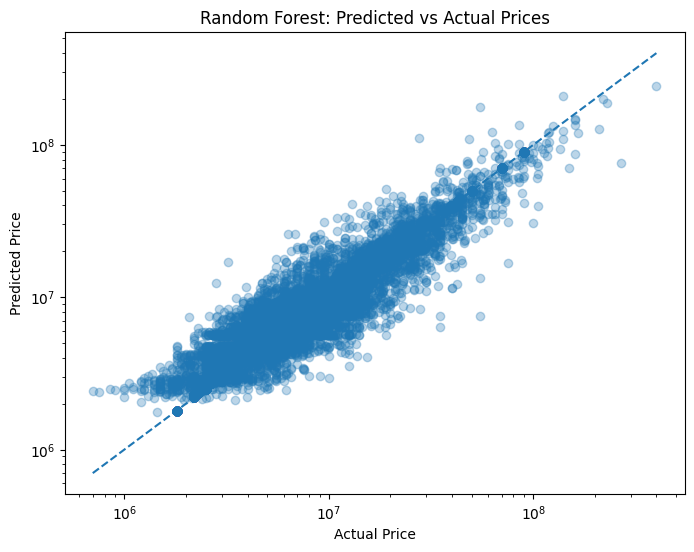

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.3)

# Perfect prediction line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual Prices")

plt.xscale("log")
plt.yscale("log")

plt.show()

In [36]:
import joblib

# Save the best model
joblib.dump(random_forest_model, "house_price.pkl")

print("Model saved successfully!")

Model saved successfully!


In [37]:
import joblib

# Load the saved model
loaded_model = joblib.load("house_price.pkl")

# Test prediction on one sample
sample = X_test.iloc[[0]]
actual_price = y_test.iloc[0]
predicted_price = loaded_model.predict(sample)[0]

print("Model loaded successfully!")
print("Actual price:", actual_price)
print("Predicted price:", predicted_price)

Model loaded successfully!
Actual price: 7500000.0
Predicted price: 7580823.719261268


In [38]:
import json

# Get the top 50 locations
locations = sorted(top_locations.tolist())

# Save locations to JSON
with open("locations.json", "w", encoding="utf-8") as f:
    json.dump(locations, f, ensure_ascii=False, indent=2)

print("locations.json created successfully!")
print("Number of locations:", len(locations))
print(locations)

locations.json created successfully!
Number of locations: 50
['agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore', 'bhiwadi', 'bhubaneswar', 'chandigarh', 'chennai', 'coimbatore', 'dehradun', 'faridabad', 'ghaziabad', 'goa', 'greater-noida', 'guntur', 'gurgaon', 'guwahati', 'hyderabad', 'jaipur', 'jamshedpur', 'kalyan', 'kanpur', 'kochi', 'kolkata', 'lucknow', 'mangalore', 'mohali', 'mumbai', 'nagpur', 'nashik', 'navi-mumbai', 'new-delhi', 'noida', 'palghar', 'panchkula', 'patna', 'pune', 'raipur', 'ranchi', 'siliguri', 'sonipat', 'surat', 'thane', 'trivandrum', 'vadodara', 'varanasi', 'vijayawada', 'visakhapatnam', 'zirakpur']
